<a href="https://colab.research.google.com/github/OlenaLysenko/Python-Sales-Performance-and-Insights-Dashboard/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data overview**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display


from google.colab import drive
drive.mount('/content/drive')

events = pd.read_csv(
    '/content/drive/MyDrive/Collab Notebooks/Mate_homework/events.csv'
)

countries = pd.read_csv(
    '/content/drive/MyDrive/Collab Notebooks/Mate_homework/countries.csv'
)


products = pd.read_csv(
    '/content/drive/MyDrive/Collab Notebooks/Mate_homework/products.csv'
)

print("===== Events =====")
display(events.head(5))

print("===== Countries =====")
display(countries.head(5))


print("===== Products =====")
display(products.head(5))


Mounted at /content/drive
===== Events =====


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


===== Countries =====


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


===== Products =====


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


#**Data cleaning**

In [3]:
#Data cleaning (events)  Пошук пропущених значень, оцінка їх долі
print(events.isna().sum())
print(events.isna().sum() / events.shape[0] * 100)
#Видалення пропущених значень
events_data = events.dropna().copy()
print(events_data.isna().sum())

print(events_data.dtypes)
#Перетворення типів даних
events_data["Order Date"] = pd.to_datetime(events_data["Order Date"])
events_data["Ship Date"] = pd.to_datetime(events_data["Ship Date"])
events_data["Order ID"] = events_data["Order ID"].astype("string")
events_data["Product ID"] = events_data["Product ID"].astype("string")

#Досліджуємо наявність дублікатів
duplicate_rows = events_data.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())
#Досліджуємо дані на наявність аномалій
events_data.describe()





Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64
Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
dtype: int64
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object
0    

,Order Date,Ship Date,Units Sold,Unit Price,Unit Cost
count,1246,1246,1246.000000,1246.000000,1246.000000
mean,2013-10-11 14:45:15.890850816,2013-11-05 11:46:07.897271296,4953.186998,264.203387,186.310088
min,2010-01-01 00:00:00,2010-01-10 00:00:00,2.000000,9.330000,6.920000
25%,2011-12-09 18:00:00,2011-12-31 12:00:00,2349.250000,81.730000,35.840000
50%,2013-10-14 00:00:00,2013-11-03 00:00:00,4980.000000,154.060000,97.440000
75%,2015-09-01 12:00:00,2015-10-07 18:00:00,7477.000000,433.372500,263.330000
max,2017-07-22 00:00:00,2017-08-31 00:00:00,9999.000000,668.270000,524.960000
std,NaN,NaN,2915.825155,216.592937,175.503652


In [4]:
#Data cleaning (countries) Пошук пропущених значень, оцінка їх долі
print(countries.isna().sum())
print(countries.isna().sum() / countries.shape[0] * 100)
#Видалення пропущених значень
countries_data = countries.dropna().copy()
print(countries_data.isna().sum())

print(countries_data.dtypes)
#Досліджуємо наявність дублікатів
duplicate_rows = countries_data.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())
#Досліджуємо дані на наявність аномалій
countries_data.describe()


name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64
name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64
name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object
0      False
1      False
2      False
3      False
4      False
       ...  
244    False
245    False
246    False
247    False
248    False
Length: 247, dtype: bool
0


,name,alpha-2,alpha-3,region,sub-region
count,247,247,247,247,247
unique,247,247,247,5,17
top,Afghanistan,AF,AFG,Africa,Latin America and the Caribbean
freq,1,1,1,59,52


In [5]:
#Data cleaning (products) Пошук пропущених значень, оцінка їх долі
print(products.isna().sum())
print(products.dtypes)
#Перетворення типів даних
products["id"] = products["id"].astype("string")
print(products.dtypes)
#Досліджуємо наявність дублікатів
duplicate_rows = products.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())
#Досліджуємо дані на наявність аномалій
products.describe()

id           0
item_type    0
dtype: int64
id            int64
item_type    object
dtype: object
id           string[python]
item_type            object
dtype: object
0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype: bool
0


,id,item_type
count,12,12
unique,12,12
top,2103,Cereal
freq,1,1


#**Data analysis and visualization**

In [6]:
#З’єднання трьох таблиць в один датафрейм
result_data = (
    events_data
    .merge(countries_data, left_on = "Country Code", right_on = "alpha-3", how="left")
    .merge(products, left_on = "Product ID", right_on = "id", how="left")
)
#Видалення непотрібних для аналізу колонок
result_data.drop(columns=["alpha-2", "alpha-3", "id"], inplace=True)

pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 2000)
#Перейменування колонок
result_data = result_data.rename(columns={"name":"country", "item_type":"category", "Sales Channel":"channel"})
#Переведення назв колонок та значень в колонці channel в нижній регістр та заміна пробілів на _
result_data.columns = result_data.columns.str.lower().str.replace(" ", "_")
result_data["channel"] = result_data["channel"].str.lower()
print(result_data.head(10))


    order_id order_date  ship_date order_priority country_code product_id  channel  units_sold  unit_price  unit_cost     country  region       sub-region         category
0  100640618 2014-10-08 2014-10-18              M          NOR       2103   online       650.0      205.70     117.11      Norway  Europe  Northern Europe           Cereal
1  100983083 2016-08-11 2016-08-11              C          SRB       2103  offline      1993.0      205.70     117.11      Serbia  Europe  Southern Europe           Cereal
2  102230632 2017-05-13 2017-06-13              L          MNE       2455   online      1171.0      109.28      35.84  Montenegro  Europe  Southern Europe          Clothes
3  103435266 2012-08-11 2012-09-18              H          SRB       1270  offline      7648.0       47.45      31.79      Serbia  Europe  Southern Europe        Beverages
4  103450715 2015-03-15 2015-04-18              H          SVK       8681   online      2220.0      651.21     524.96    Slovakia  Europe   

In [8]:
#Ключові метрики діяльності компанії:

#загальна кількість замовлень
total_order_id = len(result_data)
print(f"Загальна кількість замовлень: {total_order_id}")
#загальний прибуток
result_data["profit"] = (result_data["unit_price"] - result_data["unit_cost"]) * result_data["units_sold"]
total_profit = result_data["profit"].sum()
print(f"Загальний прибуток: ${total_profit:,.2f}")
#загальна кількість охоплених країн
total_country_count = result_data["country"].nunique()
print(f"Загальна кількість охоплених країн: {total_country_count}")
#загальна кількість проданих одиниць товару
total_units_sold = result_data["units_sold"].sum()
print(f"Загальна кількість проданих одиниць товару: {total_units_sold:,.2f}")
#загальний дохід
result_data["revenue"] = result_data["unit_price"] * result_data["units_sold"]
total_revenue = result_data["revenue"].sum()
print(f"Загальний дохід: ${total_revenue:,.2f}")
#загальна собівартість
result_data["cost"] = result_data["unit_cost"] * result_data["units_sold"]
total_cost = result_data["cost"].sum()
print(f"Загальна собівартість: ${total_cost:,.2f}")

print(result_data.head(5))

Загальна кількість замовлень: 1246
Загальний прибуток: $473,709,035.06
Загальна кількість охоплених країн: 45
Загальна кількість проданих одиниць товару: 6,171,671.00
Загальний дохід: $1,598,983,761.26
Загальна собівартість: $1,125,274,726.20
    order_id order_date  ship_date order_priority country_code product_id  channel  units_sold  unit_price  unit_cost     country  region       sub-region         category     profit     revenue        cost
0  100640618 2014-10-08 2014-10-18              M          NOR       2103   online       650.0      205.70     117.11      Norway  Europe  Northern Europe           Cereal   57583.50   133705.00    76121.50
1  100983083 2016-08-11 2016-08-11              C          SRB       2103  offline      1993.0      205.70     117.11      Serbia  Europe  Southern Europe           Cereal  176559.87   409960.10   233400.23
2  102230632 2017-05-13 2017-06-13              L          MNE       2455   online      1171.0      109.28      35.84  Montenegro  Europ

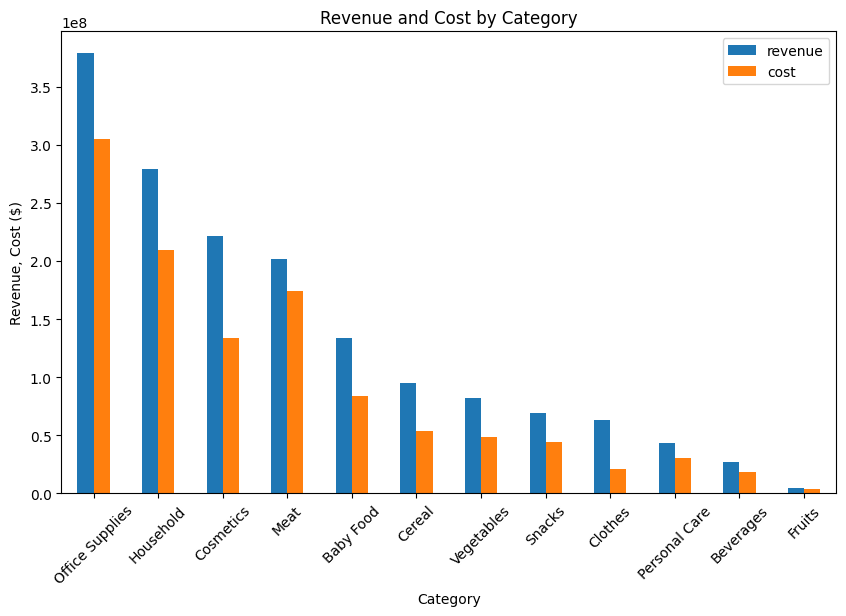

In [9]:
#Аналіз продажів в розрізі категорій товарів:
# Total revenue and cost by category
revenue_cost_by_category = result_data.groupby("category")[["revenue", "cost"]].sum().sort_values("revenue", ascending=False)
revenue_cost_by_category.plot(
    kind="bar", figsize=(10,6), xlabel="Category", ylabel="Revenue, Cost ($)", title="Revenue and Cost by Category"
)
plt.xticks(rotation=45)
plt.show()

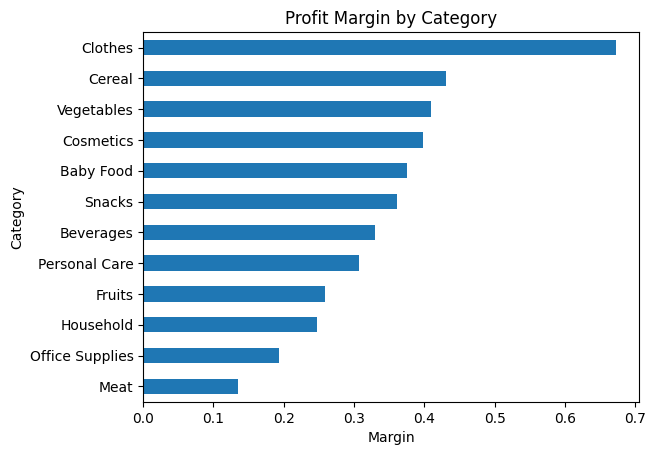

In [12]:
# Profit Margin by Category
margin_by_category = (result_data.groupby("category")[["profit", "revenue"]].sum()
)
margin_by_category["margin"] = margin_by_category["profit"] / margin_by_category["revenue"]
margin_by_category["margin"].sort_values().plot(kind = "barh", title = "Profit Margin by Category")
plt.xlabel("Margin")
plt.ylabel("Category")
plt.show()

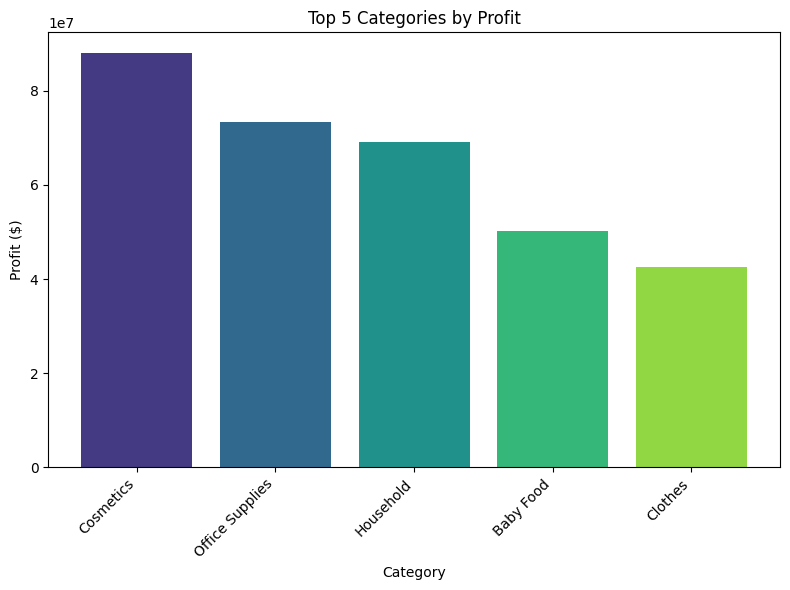

In [ ]:
#Top 5 categories by Profit
top_categories = result_data.groupby("category")["profit"].sum().nlargest(5)
colors = sns.color_palette("viridis", len(top_categories))

plt.figure(figsize=(8, 6))
plt.bar(top_categories.index, top_categories.values, color=colors)
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.title("Top 5 Categories by Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

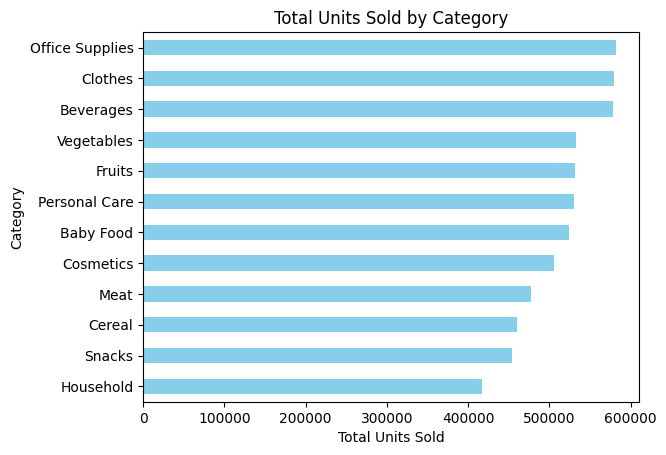

In [ ]:
# Total units_sold by category
units_sold_by_category = result_data.groupby("category")["units_sold"].sum().sort_values(ascending=False)
units_sold_by_category = units_sold_by_category[::-1]
units_sold_by_category.plot(
    kind="barh", xlabel="Total Units Sold", ylabel="Category", title="Total Units Sold by Category", color="skyblue"
)
plt.xticks(rotation=0)
plt.show()

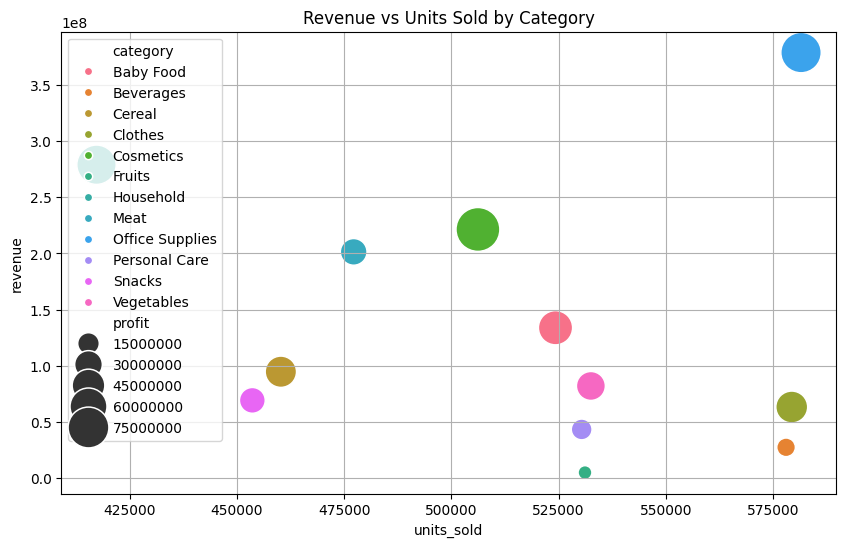

In [13]:
#Revenue vs Units Sold
category_stats = result_data.groupby("category").agg({"units_sold": "sum",
                                                      "revenue": "sum",
                                                      "profit": "sum"}).reset_index()
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=category_stats,
    x="units_sold",
    y="revenue",
    size="profit",
    hue="category",
    sizes = (100, 1000)
)
plt.title("Revenue vs Units Sold by Category")
plt.grid(True)
plt.show()

In [ ]:
# #Аналіз продажів (доходи, витрати, прибутки, популярність товарів) в розрізі країн:
import plotly.express as px

country_revenue = result_data.groupby("country")["revenue"].sum().sort_values(ascending=False).reset_index()

fig = px.choropleth(
    country_revenue,
    locations="country",
    locationmode="country names",
    color="revenue",
    hover_name="country",
    color_continuous_scale="Viridis",
    title="Total Revenue by Country"
)
fig.show()
print(country_revenue.head(5))

                  country      revenue
0          Czech Republic  53543932.14
1                 Ukraine  53252317.54
2  Bosnia and Herzegovina  50117508.49
3               Macedonia  49222085.25
4              San Marino  47883708.48


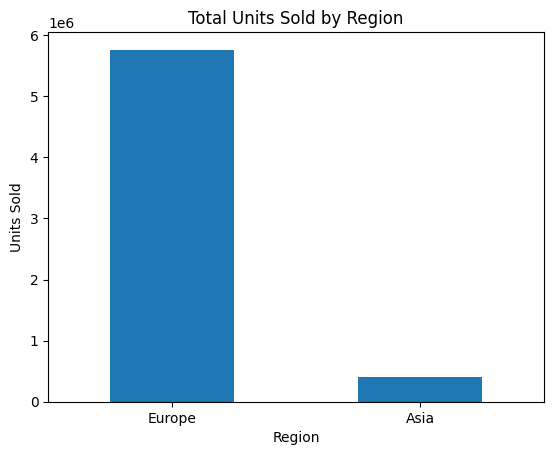

In [ ]:
# Total units_sold by region
units_sold_by_region = result_data.groupby("region")["units_sold"].sum().sort_values(ascending=False)
units_sold_by_region.plot(
    kind="bar", xlabel="Region", ylabel="Units Sold", title="Total Units Sold by Region"
)
plt.xticks(rotation=0)
plt.show()

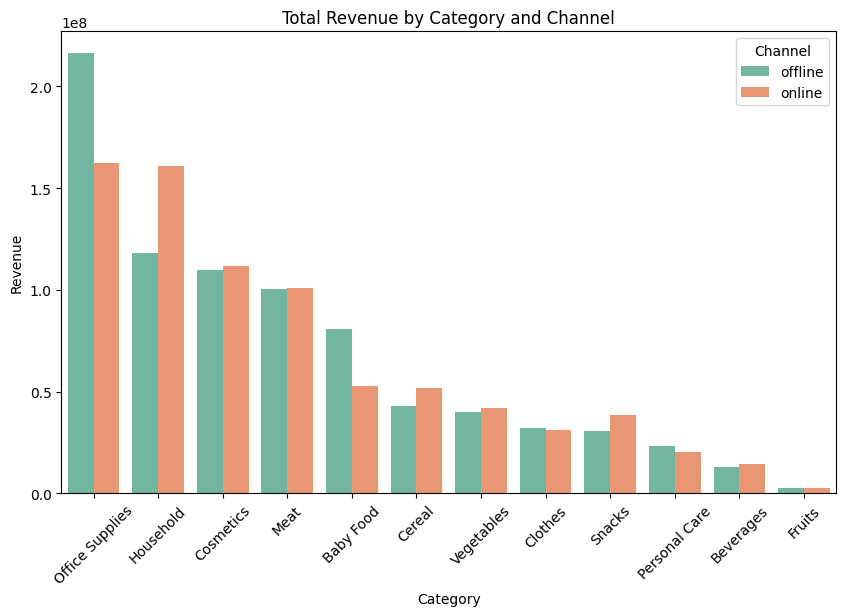

In [ ]:
#Total Revenue by Category and Channel
category_channel_revenue = result_data.groupby(["category", "channel"])["revenue"].sum().reset_index()
channel_offline = (
    category_channel_revenue[category_channel_revenue["channel"] == "offline"]
    .sort_values("revenue", ascending=False)["category"]
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=category_channel_revenue,
    x="category",
    y="revenue",
    hue="channel",
    palette="Set2",
    order=channel_offline
)
plt.title("Total Revenue by Category and Channel")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Channel")
plt.show()

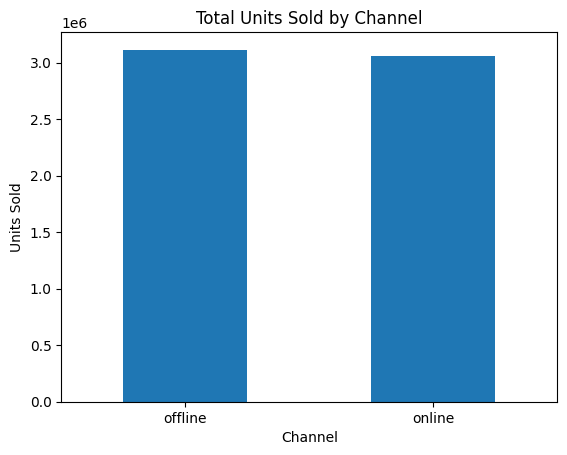

In [ ]:
# Total Units Sold by Channel
units_sold_by_channel = result_data.groupby("channel")["units_sold"].sum().sort_values(ascending=False)
units_sold_by_channel.plot(
    kind="bar", xlabel="Channel", ylabel="Units Sold", title="Total Units Sold by Channel"
)
plt.xticks(rotation=0)
plt.show()

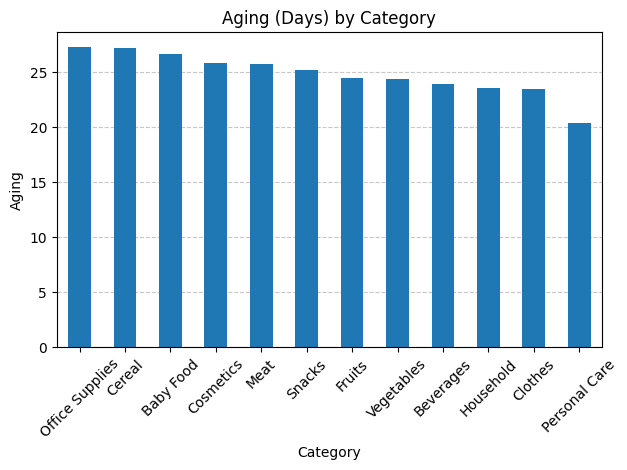

In [ ]:
#Інтервал часу між замовленням та його відвантаженням в розрізі категорій товарів:
# знаходимо інтервал часу між замовленням та його відвантаженням:
result_data["aging"] = (result_data["ship_date"] - result_data["order_date"]).dt.days
aging_by_category = result_data.groupby("category")["aging"].mean().sort_values(ascending=False)
plt.figure()
aging_by_category.plot(kind='bar')

plt.xlabel('Category')
plt.ylabel('Aging')
plt.title('Aging (Days) by Category')
plt.xticks(rotation=45)
plt.gca().set_axisbelow(True)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

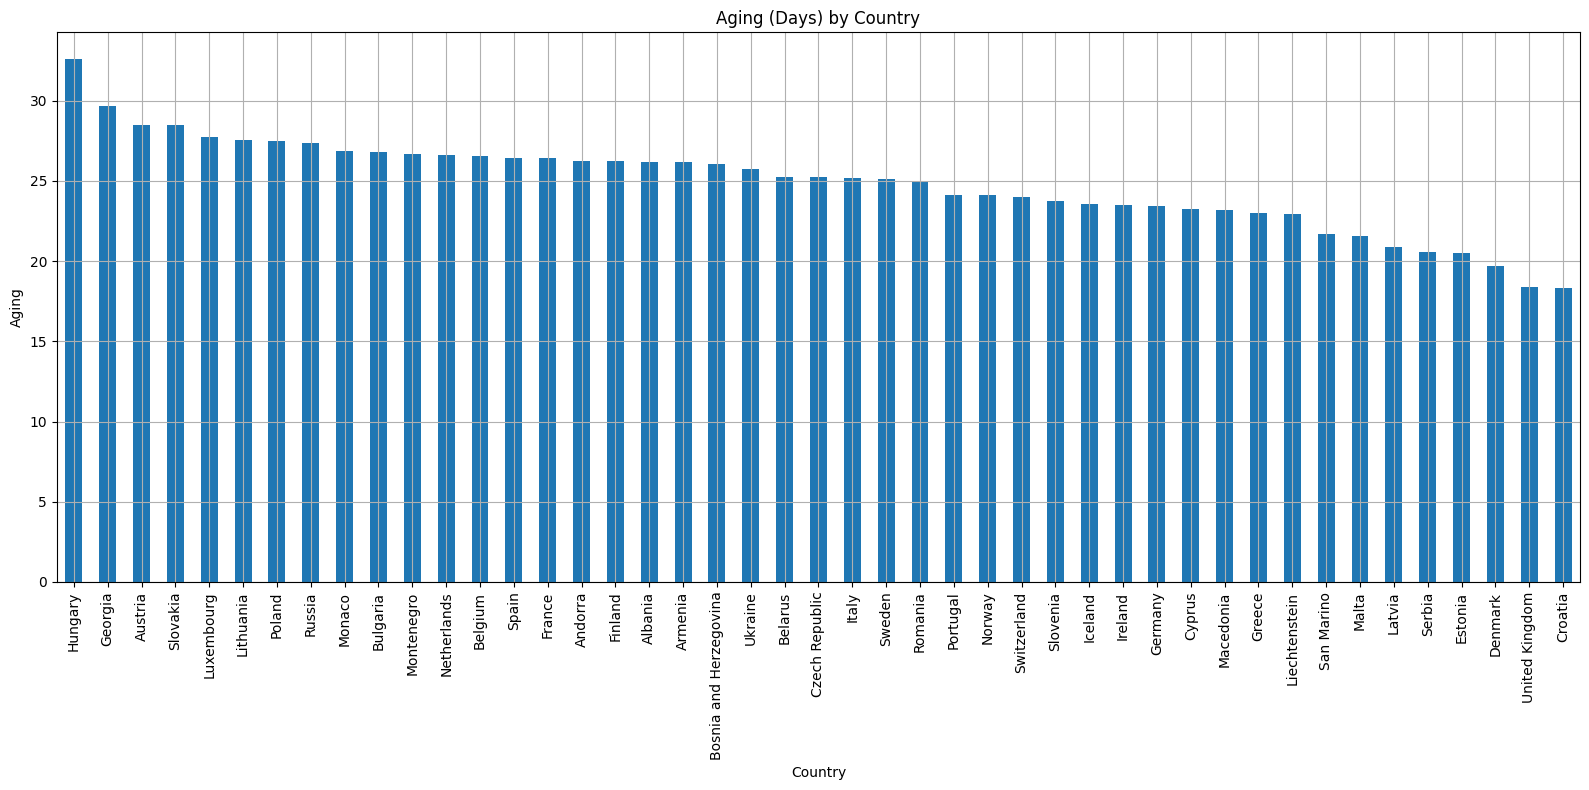

In [ ]:
#Інтервал часу між замовленням та його відвантаженням в розрізі країн:
aging_by_country = result_data.groupby("country")["aging"].mean().sort_values(ascending=False)
plt.figure(figsize=(16, 8))
aging_by_country.plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Aging')
plt.title('Aging (Days) by Country')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

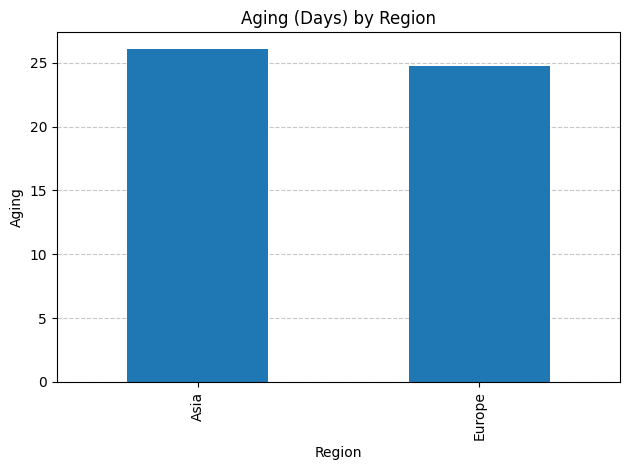

In [ ]:
#Інтервал часу між замовленням та його відвантаженням в розрізі регіонів:
aging_by_region = result_data.groupby("region")["aging"].mean().sort_values(ascending=False)
plt.figure()
aging_by_region.plot(kind='bar')

plt.xlabel('Region')
plt.ylabel('Aging')
plt.title('Aging (Days) by Region')
plt.xticks()
plt.gca().set_axisbelow(True)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

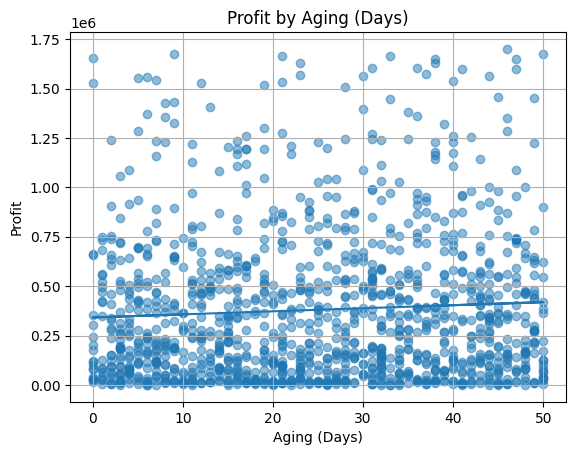

In [ ]:
#Взаємозв'язок між прибутком та часом, необхідного на відвантаження товару
plt.figure()
plt.scatter(result_data["aging"], result_data["profit"], alpha=0.5)

# Лінія тренду (лінійна регресія 1-го ступеня)
z = np.polyfit(result_data["aging"], result_data["profit"], 1)
p = np.poly1d(z)

plt.plot(result_data["aging"], p(result_data["aging"]))

plt.xlabel('Aging (Days)')
plt.ylabel('Profit')
plt.title('Profit by Aging (Days)')

plt.grid(True)
plt.show()


Топ-3 категорій: Index(['Office Supplies', 'Household', 'Cosmetics'], dtype='object', name='category')


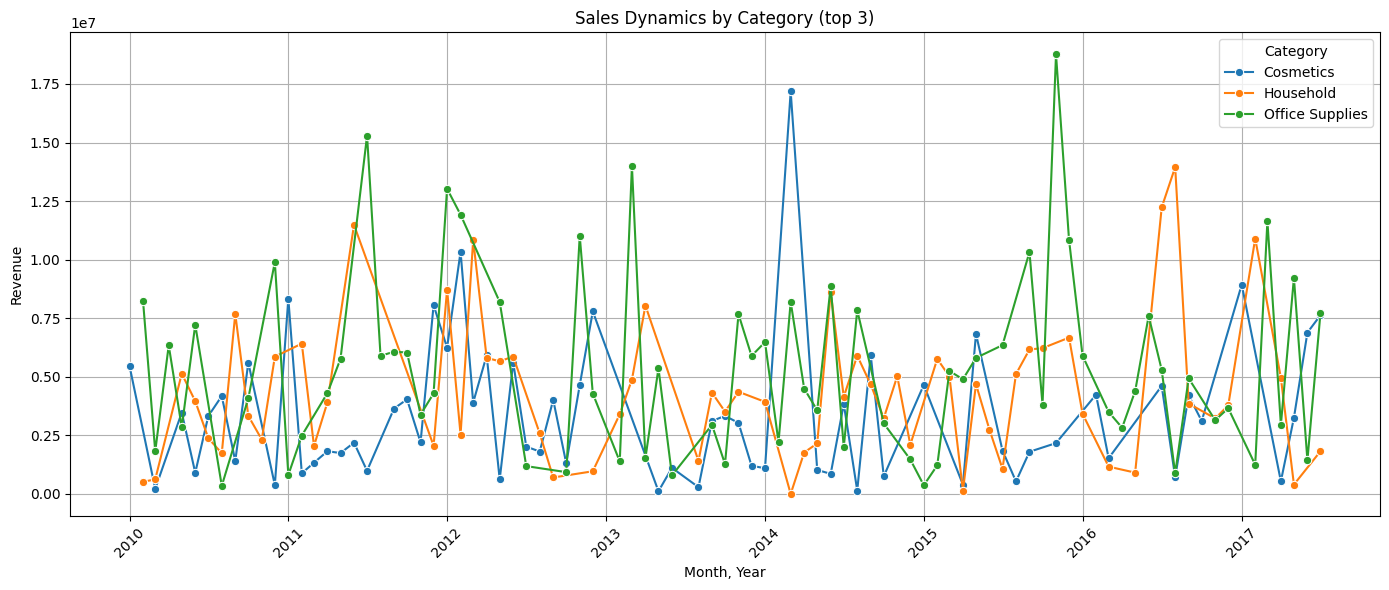

In [ ]:
#Динаміка продажів (у часі) у розрізі категорій товарів (топ 3)
top_categories = result_data.groupby("category")["revenue"].sum().sort_values(ascending=False).head(3).index
print("Топ-3 категорій:", top_categories)
#виокремлюємо місяці в кожному році
result_data["year_month"] = result_data["order_date"].dt.to_period('M')

monthly_sales = result_data.groupby(["year_month", "category"])["revenue"].sum().reset_index()
monthly_sales["year_month"] = monthly_sales["year_month"].dt.to_timestamp()
monthly_sales_top3 = monthly_sales[monthly_sales["category"].isin(top_categories)]

plt.figure(figsize=(14,6))
sns.lineplot(data=monthly_sales_top3, x="year_month", y="revenue", hue="category", marker="o")
plt.title("Sales Dynamics by Category (top 3)")
plt.xlabel("Month, Year")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()
plt.grid(True)
plt.show()

Топ-3 країн: Index(['Czech Republic', 'Ukraine', 'Bosnia and Herzegovina'], dtype='object', name='country')


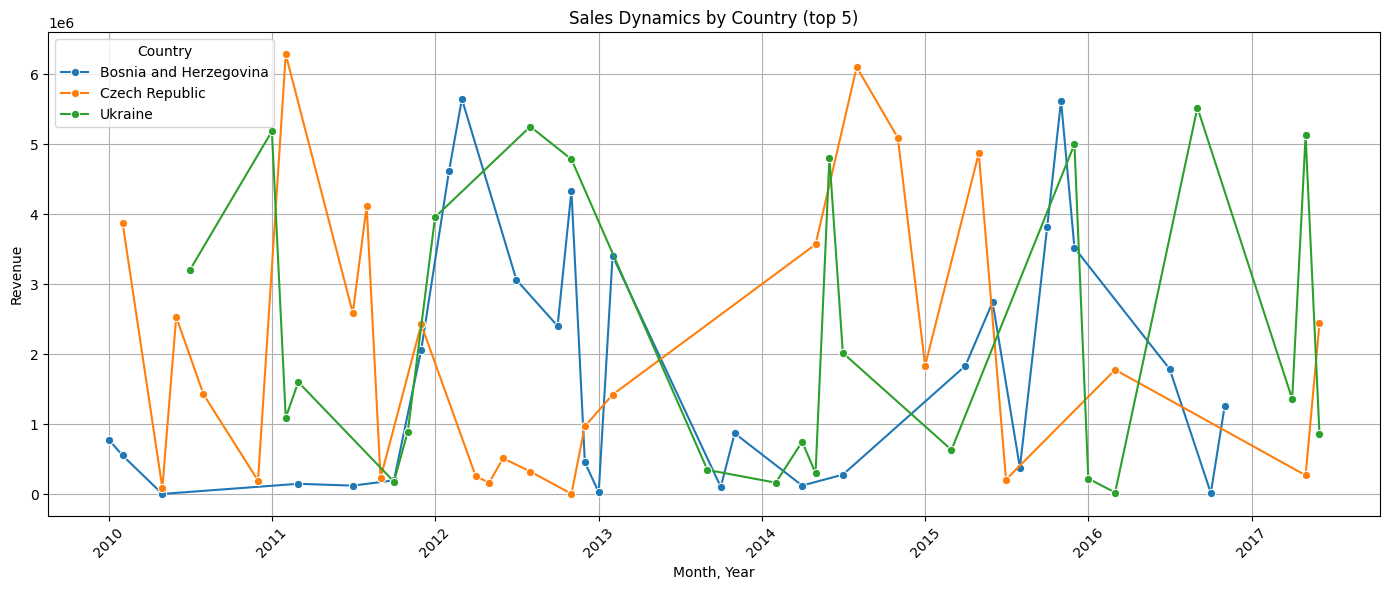

In [ ]:
#Динаміка продажів (у часі) у розрізі країн (топ 3)

top_countries = result_data.groupby("country")["revenue"].sum().sort_values(ascending=False).head(3).index
print("Топ-3 країн:", top_countries)
#виокремлюємо місяці в кожному році
result_data["year_month"] = result_data["order_date"].dt.to_period('M')

country_sales = result_data.groupby(["year_month", "country"])["revenue"].sum().reset_index()
country_sales["year_month"] = country_sales["year_month"].dt.to_timestamp()
country_sales_top3 = country_sales[country_sales["country"].isin(top_countries)]

plt.figure(figsize=(14,6))
sns.lineplot(data=country_sales_top3, x="year_month", y="revenue", hue="country", marker="o")
plt.title("Sales Dynamics by Country (top 5)")
plt.xlabel("Month, Year")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Country")
plt.tight_layout()
plt.grid(True)
plt.show()

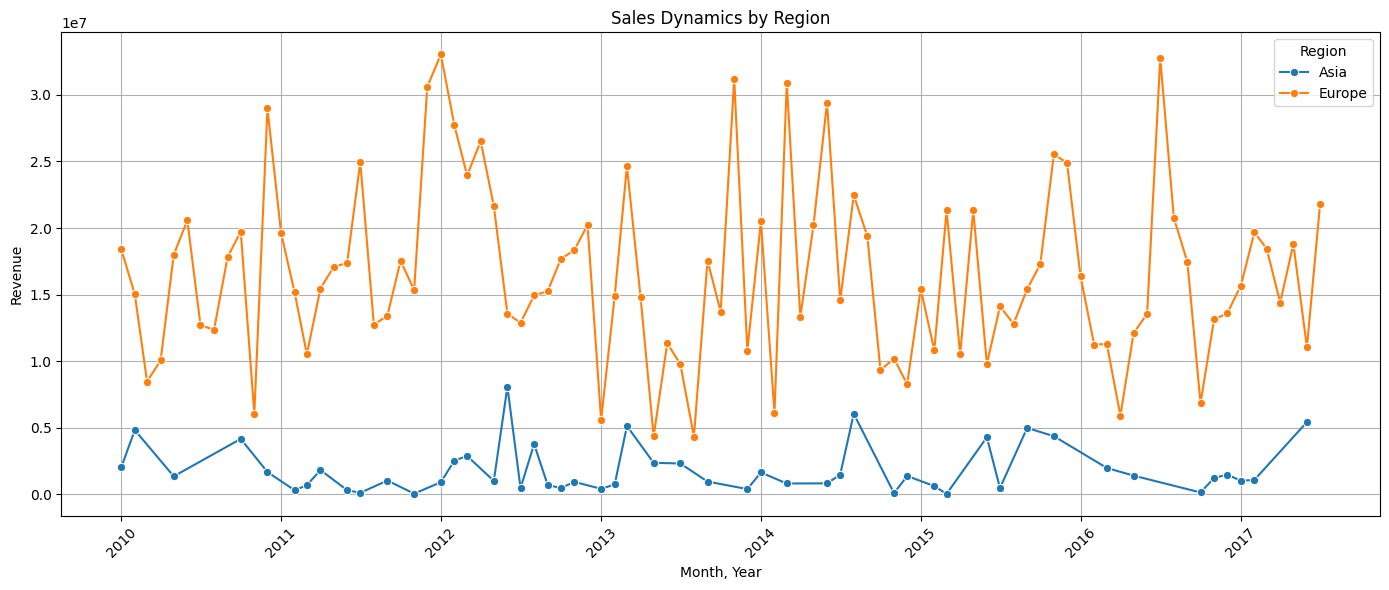

In [ ]:
#Динаміка продажів (у часі) у розрізі регіонів

result_data["year_month"] = result_data["order_date"].dt.to_period('M')
region_sales = result_data.groupby(["year_month", "region"])["revenue"].sum().reset_index()
region_sales["year_month"] = region_sales["year_month"].dt.to_timestamp()


plt.figure(figsize=(14,6))
sns.lineplot(data=region_sales, x="year_month", y="revenue", hue="region", marker="o")
plt.title("Sales Dynamics by Region")
plt.xlabel("Month, Year")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.tight_layout()
plt.grid(True)
plt.show()

  order_date day_of_week
0 2014-10-08   Wednesday
1 2016-08-11    Thursday
2 2017-05-13    Saturday
3 2012-08-11    Saturday
4 2015-03-15      Sunday


/tmp/ipython-input-34973304.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




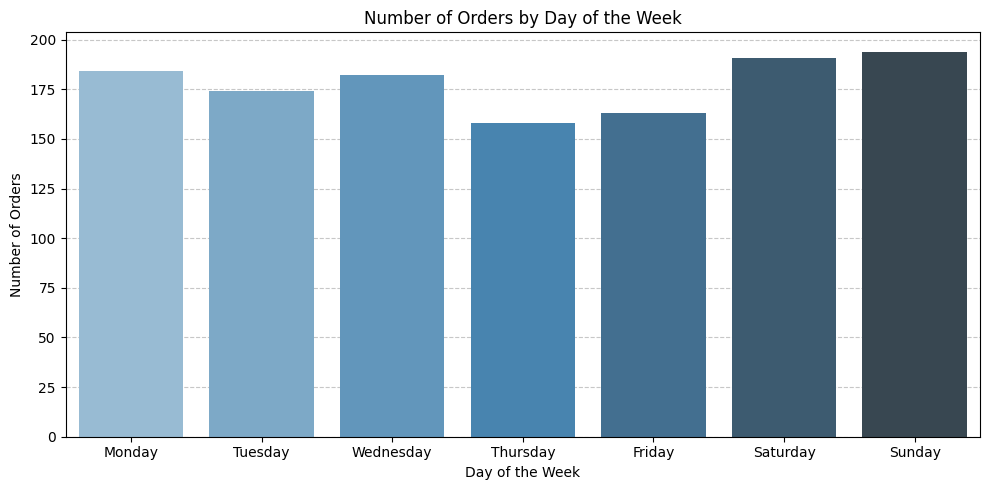

In [ ]:
#Аналіз продажів товарів за днями тижня

#Знаходження дня тижня за датою за методом day_name().
result_data["day_of_week"] = result_data["order_date"].dt.day_name()
print(result_data[["order_date", "day_of_week"]].head(5))
#групуємо і впорядковуємо дні тижня у правильному порядку
weekly_orders = result_data.groupby("day_of_week")["order_id"].count().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=weekly_orders, x="day_of_week", y='order_id', palette='Blues_d')
plt.title("Number of Orders by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Orders")
plt.gca().set_axisbelow(True)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()





<Figure size 1200x600 with 0 Axes>

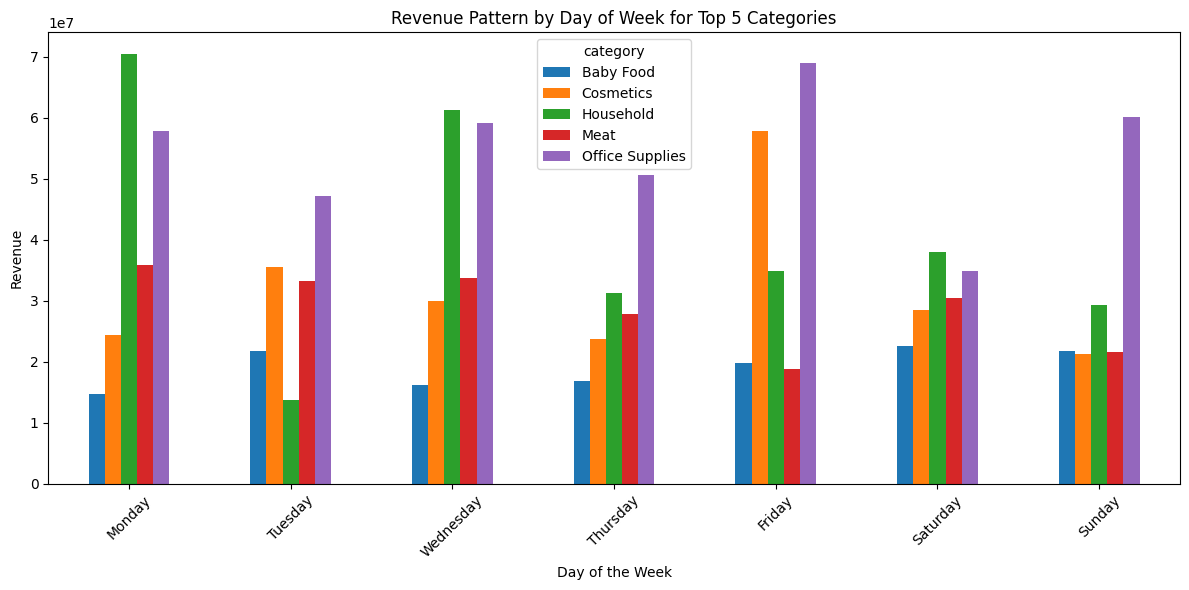

In [ ]:
#Аналіз продажів товарів за днями тижня (топ 5 категорій)
top_products = result_data.groupby("category")["revenue"].sum().sort_values(ascending=False).head(5).index
top_data = result_data[result_data["category"].isin(top_products)]
#створємо зведену таблицю pivot table, щоб бачити скільки кожна категорія заробляє кожного дня
pivot_top = top_data.pivot_table(index="category", columns="day_of_week", values="revenue", aggfunc="sum", fill_value=0)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_top = pivot_top[days_order]

plt.figure(figsize=(12,6))
pivot_top.T.plot(kind="bar", figsize=(12,6))
plt.title("Revenue Pattern by Day of Week for Top 5 Categories")
plt.xlabel("Day of the Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="category")
plt.tight_layout()
plt.show()


##**Reporting**


---
###***Data overview***

- таблиця **Events** містить інформацію щодо продажів за декілька років, а саме: дані про замовлення продуктів у різних країнах, включно з інформацією про дату замовлення, дату відправки, пріоритет замовлення, країну, ідентифікатор продукту, канал продажу, кількість одиниць, ціну за одиницю та собівартість;
- таблиця **Countries** містить інформацію щодо кожної країни, а саме: код країни, регіон та субрегіон, до якого вона відноситься;
- таблиця **Products** містить інформацію щодо id продукту і до якого типу(категорії) належить цей продукт.
#####**Ключові поля:**
- для таблиць Events та Countries - Country Code та alpha-3 відповідно;
- для таблиць Events та Products - Product ID та id відповідно.


---

###***Data cleaning (events)***
- у колонці Country Code пропущено 6% значень, а в Units Sold — лише 0.15%. Причинами таких пропущень можуть бути помилка під час введення даних або невведеня даних взагалі, дані про Units Sold могли бути відсутні через технічні збої або затримки у системі. Це невелика частка від усіх даних, тому видалення цих рядків не сильно спотворить статистику;
- дублікатів немає;
- аномалій не спостерігається.

### ***(countries)***
- частка пропущених значень ~ 0,4%. Це невелика частка від усіх даних, тому видалення цих рядків не сильно спотворить статистику;
- дублікатів немає;
- аномалій не спостерігається.

###***(products)***
- пропущених значень немає;
- дублікатів немає;
- аномалій не спостерігається.


---

###***Data analysis and visualization***
#### **Ключові метрики діяльності компанії:**
* загальна кількість замовлень: 1246
* загальний прибуток: $473,709,035.06  

* загальна кількість охоплених країн: 45
* загальна кількість проданих одиниць товару: 6,171,671.00

* загальний дохід: $1,598,983,761.26

* загальна собівартість: $1,125,274,726.20


####**Аналіз продажів** (доходи, витрати, прибутки, популярність товарів)


1.   В розрізі категорій товарів:

*   Office Supplies, Household, Cosmetics, Meat - найбільші за доходом категорії;
*   Cosmetics, Baby Food, Cereal, Vegetables - категорії з хорошою маржинальністю;

*   Cosmetics, Office Supplies, Household, Baby Foofd, Clothes - топ 5 категорій по прибутку;
*   Office Supplies, Clothes, Beverages - топ 3 категорії по кількості проданих одиниць;
* Clothes - найбільш вигідна категорія (має найбільшу маржу Profit Margin);
* Office Supplies - категорія, яка одночасно має високій дохід і великий прибуток.

2.   В розрізі географії (країн, регіонів):

*   Czech Republic, Ukraine, Bosnia and Herzegovina, Macedonia, San Marino - топ 5 країн з найбільшим прибутком.

*   обсяг продажів у регіоні Європа перевищує показники у Азії майже в 10 разів.

3.   В розрізі каналів продажу (online, offline):


*   Offline продажі переважають над Online в категоріях Office Supplies, Baby Food, Clothes, Personal Care;
* загальна кількість проданих одиниць майже однакова через канали продажу offline та online.

####**Інтервал часу між замовленням та його відвантаженням:**

1.   В розрізі категорій товарів:

*   середній інтервал часу знаходиться в межах 21-28 днів для усіх категорій товару;

2.   В розрізі країн та регіонів:

*   Hungary, Georgia, Austria, Slovakia мають найбільший середній інтервал часу між замовленням та його відвантаженням
*   в обох регіонах приблизно однаковий середній інтервал часу між замовленням та його відвантаженням.

#### **Взаємозв'язок між прибутком та часом, необхідного на відвантаження товару**:

*   кореляція між прибутком та часом, необхідного для відвантаження товару слабка або майже відсутня;
*   для будь-якого значення часу прибуток сильно коливається.

#### Основні тенденції динаміки продажів (у часі):  

1.   У розрізі категорій товарів (топ 3):

*   усі топ 3 категорії за продажем Office Supplies, Household, Cosmetics демонструють високу волатильність;
*   чітко визначеного стабільного довгострокового тренду зростання немає;

*   спостерігаються регулярні пікові значення, що може свідчити про сезонність або акційні періоди.

2.   У розрізі країн (топ 3):

*   Чехія демонструє абсолютні максимуми доходів у 2011 та 2015 роках, попри значні падіння країна швидко відновлюється до високих результатів;
*   Україна демонструє періоди дуже стрімкого зростання у 2011, 2012 та 2016 роках, у 2014 та 2016 роках спостерігаються періоди, коли доходи падали майже до нульової позначки.

3.   У розрізі регіонів:

*   продажі у регіоні Європа стабільно та суттєво перевищують регіон Азія;
*   продажі не мають лінійного тренду, обидва регіони демонструють високу амплітуду коливань від місяця до місяця;

*   попри наявність високих піків, загальний довгостроковий тренд виглядає стагнаційним або горизонтальним; рівень продажів у 2017 році приблизно відповідає рівню 2010 року, без явного прогресу в обсягах продажу.

####**Аналіз продажів товарів за днями тижня**

*   найбільша кількість замовлень спостерігається в понеділок, середу, суботу та неділю;
*   товари категорій Household, Office Supplies та Cosmetics можна вважати циклічними (в залежності від дня тижня).


---



##**Conclusions**

*   Попри те, що категорія «Cosmetics» посідає лише 3-тє місце за загальною виручкою, вона є абсолютним лідером за прибутком. Це свідчить про найкраще співвідношення ціни та собівартості;
*   Категорія Office Supplies генерує найбільшу виручку та має найбільшу кількість проданих одиниць, що робить її критично важливою для підтримки грошового потоку та оборотності;

*   Категорії Fruits/Beverages мають найнижчі показники як за обсягом продажів, так і за прибутком, що ставить під питання доцільність розширення їхнього асортименту;
*   Європа генерує в рази більше виручки та обсягів продажу порівняно з Азією; бізнесу варто продовжувати інвестувати в європейський ринок як у найбільш стабільне джерело доходу;

*   Продажі в усіх країнах надзвичайно нестабільні, це свідчить про відсутність бази лояльних клієнтів з регулярними закупівлями;
*   Скорочення терміну обробки замовлень дозволить швидше вивільняти обігові кошти.





























